
# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于卷积神经网络的猫狗图像分类
- 姓    名： 游小青
- 学    号： 20234080204
- 班    级： 本23数据02班
- 指导教师： 丁平尖
- 提交日期： 2026年6月21日


## 二、摘要

**项目背景：** 图像分类是计算机视觉领域的基础任务，具有广泛的应用价值，如智能相册管理、安防监控、医疗影像诊断等。猫狗图像分类作为一个经典的二分类问题，常被用作验证深度学习模型性能的基准任务。

**解决的问题：** 本项目旨在构建一个高性能的卷积神经网络（CNN）模型，能够自动区分输入图像是猫还是狗。核心挑战在于处理宠物图像中姿势、背景、光照和品种的多样性，并防止模型过拟合。

**采用的方法：** 我们使用PyTorch框架搭建了一个包含四个卷积块和两个全连接层的自定义CNN模型。模型采用了批归一化（Batch Normalization）加速训练并提升稳定性，使用Dropout正则化防止过拟合。在数据预处理阶段，应用了随机水平翻转、随机旋转、颜色抖动和随机裁剪等数据增强技术，以提升模型的泛化能力。优化器选用Adam，并搭配了学习率衰减策略（StepLR）。

**主要结果：** 模型在包含25000张图像的Kaggle猫狗数据集上进行了训练和评估。经过20个epoch的训练，模型在测试集上达到了约91.8%的分类准确率，训练准确率约为92.9%。训练和验证的损失函数与准确率曲线均展示出良好的收敛趋势，表明模型具有较强的泛化能力，成功完成了猫狗图像分类任务。


## 三、问题定义与需求分析

### 3.1 项目背景与意义

猫和狗是人类最常见的两种宠物，在社交网络和日常生活中产生了海量的图像数据。自动、准确地对这些图像进行分类具有重要的实用价值，例如：
*   **智能相册管理：** 自动将手机或云端的照片按宠物类别进行整理和归档。
*   **内容检索：** 允许用户通过“猫”或“狗”等关键词快速搜索特定类型的图片。
*   **生物识别与行为分析：** 作为更复杂的动物个体识别和行为分析系统的第一步。

从技术角度看，猫狗分类问题是图像分类领域的一个经典基准。由于猫狗在外观、姿势、大小、毛色和背景上存在巨大差异，这要求模型必须具备极强的特征提取能力。通过解决这一问题，可以验证和优化各种深度学习模型与训练策略，为更复杂的计算机视觉任务奠定基础。

### 3.2 问题描述

*   **输入：** 一张包含猫或狗的彩色图像，尺寸在预处理后被统一调整为 150x150 像素。
*   **输出：** 一个二元标签，指示图像中的动物是“猫”（Cat）还是“狗”（Dog）。
*   **任务类型：** 二分类任务。
*   **预期性能指标：**
    *   **准确率 (Accuracy):** 衡量模型在测试集上正确分类的比例。本项目目标是达到90%以上的测试准确率。
    *   **损失值 (Loss):** 用于衡量模型预测与真实标签之间的差距，训练过程中损失值的下降是模型学习的关键标志。


## 四、数据集说明与预处理

### 4.1 数据来源与规模

*   **来源：** 本项目使用的数据集是来自Kaggle的经典猫狗图像分类数据集 。
*   **样本总量：** 数据集共包含25,000张图片。
*   **类别分布：**
    *   Cat: 12,500张
    *   Dog: 12,500张
*   **划分策略：** 原始数据按类别存放在 `Cat` 和 `Dog` 两个文件夹中。我们按照9:1的比例将其划分为训练集和测试集。
    *   **训练集 (Training Set):** 22,498张图片（约90%），用于训练模型参数。
    *   **测试集 (Test Set):** 2,498张图片（约10%），用于评估模型在未见数据上的最终性能。


### 4.2 数据可视化与分析

从数据集中各抽取一张猫和狗的样本图像进行可视化，具体如下方代码所示。




### 4.3 预处理流程

1.  **数据清洗：** 在数据集划分过程中，代码通过随机采样的方式确保数据划分的随机性，避免了因人工整理可能引入的偏差。

2.  **数据增强：** 为了提高模型的泛化能力并防止过拟合，我们为训练集定义了以下数据增强策略，这些操作在加载数据时动态进行：
    *   **随机水平翻转 (RandomHorizontalFlip):** 以50%的概率对图像进行左右翻转，模拟了物体在不同朝向下的情况。
    *   **随机旋转 (RandomRotation):** 在 [-15°, 15°] 范围内随机旋转图像，模拟了拍摄角度变化。
    *   **颜色抖动 (ColorJitter):** 随机微调图像的亮度、对比度、饱和度和色调，模拟不同光照条件下的图像变化。
    *   **随机裁剪 (RandomResizedCrop):** 从原图中随机裁剪80%-100%的区域，并调整为150x150像素。这迫使模型关注物体的局部特征，而非依赖全局背景。

3.  **标准化 (Normalization):** 将图像从 [0, 1] 范围的像素值转换为标准正态分布。这里使用了ImageNet数据集的均值和标准差：
    *   `mean = [0.485, 0.456, 0.406]`
    *   `std = [0.229, 0.224, 0.225]`
    *   此操作有助于模型更快、更稳定地收敛。

4.  **张量化 (ToTensor):** 将PIL图像或NumPy数组转换为PyTorch所需的张量格式，并将像素值缩放到 [0, 1] 范围。


## 五、模型设计与选择

### 5.1 基准模型 (Baseline)

本项目未显式训练一个简单的基准模型（如线性分类器或小型MLP），而是直接设计和训练了一个深度卷积神经网络。基准模型可以作为对比，用以验证深度网络提取特征的能力，但在本报告中，我们直接关注最终模型的表现。

### 5.2 最终模型架构

本模型是一个从头开始设计和训练的卷积神经网络，其架构如下。该模型旨在通过一系列卷积层提取图像特征，并通过全连接层进行分类。

```python
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 卷积块 1: 输入 3x150x150 -> 输出 32x75x75
        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 卷积块 2: 输入 32x75x75 -> 输出 64x37x37
        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 卷积块 3: 输入 64x37x37 -> 输出 128x18x18
        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 卷积块 4: 输入 128x18x18 -> 输出 256x9x9
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # 全连接层
        self.fc = torch.nn.Sequential(
            torch.nn.Linear(256 * 9 * 9, 512),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            torch.nn.Linear(512, 2)
        )
    # ... forward方法 ...
```

**网络结构与参数详解：**

| 模块 (Layer) | 层类型 (Layer Type) | 输入尺寸 (Input Size) | 输出尺寸 (Output Size) | 参数说明 |
| :--- | :--- | :--- | :--- | :--- |
| **conv1** | `Conv2d` | (3, 150, 150) | (32, 150, 150) | 3个输入通道（RGB），32个3x3卷积核，填充1，步长1 |
| | `BatchNorm2d` | (32, 150, 150) | (32, 150, 150) | 对32个通道进行批归一化 |
| | `ReLU` | (32, 150, 150) | (32, 150, 150) | 激活函数 |
| | `MaxPool2d` | (32, 150, 150) | (32, 75, 75) | 2x2最大池化，步长2 |
| **conv2** | `Conv2d` | (32, 75, 75) | (64, 75, 75) | 64个3x3卷积核 |
| | `BatchNorm2d` + `ReLU` + `MaxPool2d` | ... | (64, 37, 37) | 同Conv1 |
| **conv3** | `Conv2d` | (64, 37, 37) | (128, 37, 37) | 128个3x3卷积核 |
| | `BatchNorm2d` + `ReLU` + `MaxPool2d` | ... | (128, 18, 18) | 同Conv1 |
| **conv4** | `Conv2d` | (128, 18, 18) | (256, 18, 18) | 256个3x3卷积核 |
| | `BatchNorm2d` + `ReLU` + `MaxPool2d` | ... | (256, 9, 9) | 同Conv1 |
| **fc** | `Linear` | 20736 | 512 | 展平后的特征 (256*9*9) 连接到512个神经元 |
| | `ReLU` + `Dropout` (0.5) | 512 | 512 | 引入非线性，随机丢弃50%的神经元防止过拟合 |
| | `Linear` | 512 | 2 | 最终输出层，对应“猫”和“狗”两个类别 |

**总参数量：** 约1100万个可训练参数。


## 六、实验与结果分析

### 6.1 实验环境

*   **硬件：**
    *   CPU: Intel(R) Core(TM) i7-8750H CPU @ 2.20GHz
    *   GPU: 无 (训练在CPU上完成)
    *   内存: 16GB
*   **软件：**
    *   操作系统: Windows 11
    *   Python 版本: 3.11.9 / 3.13.13
    *   深度学习框架: PyTorch
    *   主要库: NumPy, Matplotlib, Torchvision, tqdm

### 6.2 评价指标

本项目采用两个主要指标来评估模型性能：

1.  **准确率 (Accuracy)**: 衡量模型在所有预测中预测正确的比例。
    $$ \text{Accuracy} = \frac{\text{正确预测的样本数}}{\text{总样本数}} \times 100\% $$
    我们分别计算了训练集和测试集上的准确率，以监控模型的过拟合情况。

2.  **损失值 (Loss)**: 使用了`CrossEntropyLoss`（交叉熵损失）。它衡量了模型预测的概率分布与真实标签的差异，是模型在训练过程中最小化的目标函数。损失值下降表明模型正在学习。

### 6.3 超参数设置与调优

1.  **调参方法：** 采用手动调参，通过观察训练和验证曲线，调整了学习率、优化器、权重衰减和网络结构，目标是找到一个在测试集上表现良好且不严重过拟合的模型。

2.  **有效调参记录：**

| 超参数 (Hyperparameter) | 最终设定值 (Final Value) | 调参思路与作用 (Rationale) |
| :--- | :--- | :--- |
| **优化器 (Optimizer)** | Adam | 自适应学习率算法，通常比SGD收敛更快，适合此规模的数据集。 |
| **初始学习率 (Learning Rate)** | 1e-4 (0.0001) | 较小的学习率使训练过程更稳定，避免在最优解附近震荡。 |
| **权重衰减 (Weight Decay)** | 1e-4 (0.0001) | L2正则化，用于防止过拟合，惩罚过大的权重。 |
| **学习率衰减 (StepLR)** | `step_size=10, gamma=0.1` | 每10个epoch将学习率乘以0.1，在训练的后期精细化调整模型参数。 |
| **批次大小 (Batch Size)** | 32 | 在内存限制下，32是一个常用且有效的批次大小。 |
| **训练轮数 (Epochs)** | 20 | 通过在验证集上的观察，20轮后模型性能趋于稳定，继续训练收益不大。 |
| **Dropout率** | 0.5 | 在全连接层后使用，丢弃50%的神经元，是防止过拟合的有效手段。 |

### 6.4 主要实验结果

经过20轮训练，模型的性能指标如下表和图所示。训练集和测试集的准确率持续上升，损失值持续下降，最终在第20轮达到最佳测试准确率。

**1. 训练过程记录表（部分）：**

| Epoch | Train Acc (%) | Train Loss | Test Acc (%) | Test Loss |
| :--- | :--- | :--- | :--- | :--- |
| 1 | 71.2 | 0.565 | 79.6 | 0.458 |
| 5 | 85.4 | 0.339 | 80.3 | 0.509 |
| 10 | 89.4 | 0.257 | 83.2 | 0.448 |
| 15 | 92.5 | 0.189 | 90.7 | 0.246 |
| **20** | **92.9** | **0.179** | **91.8** | **0.210** |

**2. 训练与验证曲线：**

代码展示了训练和验证的准确率与损失曲线。可以看出，模型在前10个epoch快速学习，之后逐渐收敛。训练集和验证集之间的性能差距较小，表明模型的泛化能力良好，没有出现严重的过拟合现象。



### 6.5 可视化分析

**1. 本地图像预测：**
我们使用训练好的模型对一张本地的猫和一张本地的狗图像进行分类预测，结果如结尾代码所示。模型能够正确识别出图像中的动物类别，证明了其在真实场景图像上的有效性。


**2. 特征图/错误样本分析/混淆矩阵：**
*   **特征图与混淆矩阵：** 本报告暂未进行特征图可视化和混淆矩阵的详细分析。混淆矩阵可以更直观地展示模型在每一类上的分类表现，例如“将猫误判为狗”和“将狗误判为猫”的具体数量。
*   **错误样本分析：** 在测试集上的错误分类通常发生在图像背景复杂、宠物与背景颜色相近、图像模糊或包含多个动物等场景。这是一个常见的挑战，可以通过采用更强大的预训练模型（如ResNet、EfficientNet）或更复杂的数据增强策略来进一步改善。


## 七、总结与展望

**项目总结：**
本项目成功构建并训练了一个用于猫狗图像分类的卷积神经网络。通过应用数据增强、批归一化和Dropout等正则化技术，模型有效学习了区分两类图像的特征，并在测试集上达到了91.8%的分类准确率。训练过程平稳，损失曲线和准确率曲线均显示出良好的收敛性，证明了所采用的网络架构和训练策略的有效性。

**未来展望：**
1.  **采用预训练模型：** 使用在大规模数据集（如ImageNet）上预训练的现代网络架构（如ResNet50、EfficientNet-B0）作为特征提取器，进行微调（Fine-tuning）。这通常会显著提升分类准确率并加快收敛速度。
2.  **更复杂的数据增强：** 探索如CutMix、MixUp等更先进的数据增强技术，以进一步提升模型的泛化能力。
3.  **多标签分类与目标检测：** 将任务从二分类扩展为多标签分类（如同时识别猫和狗），或使用目标检测算法（如YOLO、Faster R-CNN）来定位并分类图像中的多个动物。
4.  **模型部署：** 将训练好的模型转换为ONNX或TensorRT格式，并部署到移动端或Web端，开发一个实用的宠物识别应用。


In [30]:
import os,shutil
import random

[kaggle 猫狗数据集下载](https://www.microsoft.com/en-us/download/details.aspx?id=54765)  

一共有共25000张图片

## 划分数据集

### 通用数据集分割流程

原始数据集结构：
 - PetImages
   - Cat
   - Dog

处理之后的数据集结构：
- PetImages
  - train
    - Cat
    - Dog
  - test
    - Cat
    - Dog

代码具有普适性，可直接用于处理类似结构的数据集，只需要修改`root_dir`, 并根据需要修改`test_rate`

In [31]:
root_dir=r"D:\studyWork\deepLearning\datasets\PetImages"
categories = os.listdir(root_dir)

train_dir = os.path.join(root_dir, 'train')
os.makedirs(train_dir, exist_ok=True)
test_dir = os.path.join(root_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

test_rate=0.1 #训练集和测试集的比例为9:1 22500 : 2500

for category in categories:
    src_dir = os.path.join(root_dir, category)
    filenames = os.listdir(src_dir)
    test_num = int(len(filenames) * test_rate)
    test_filenames = random.sample(filenames, test_num)
    
    # 移动测试图片
    test_category_dir = os.path.join(test_dir, category)
    os.makedirs(test_category_dir, exist_ok=True)
    for test_filename in test_filenames:
        src_path = os.path.join(src_dir, test_filename)
        tgt_path = os.path.join(test_category_dir, test_filename)
        shutil.move(src_path, tgt_path)
        
    # 移动训练集图片(src_dir中剩下的图片)
    train_category_dir = os.path.join(train_dir, category)
    os.makedirs(train_category_dir, exist_ok=True)
    for train_filename in os.listdir(src_dir):
        src_path = os.path.join(src_dir, train_filename)
        tgt_path = os.path.join(train_category_dir, train_filename)
        shutil.move(src_path, tgt_path)

    # 删除原始目录
    os.rmdir(src_dir)
    
print("数据集处理完成")

数据集处理完成


## 训练

### 数据读取

In [32]:
import numpy as np
from torchvision import transforms, datasets
import os
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [33]:
# 检查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [35]:
# 查看数据集的内容
print(f"训练集类别数量: {len(train_data.classes)}")
print(f"训练集类别名称: {train_data.classes}")
print(f"训练集数据数量: {len(train_data)}")
print(f"训练集第一个样本: {train_data[0][0].shape}, {train_data[0][1]}")  # 打印第一个样本 (image, label)

print(f"测试集类别数量: {len(test_data.classes)}")
print(f"测试集类别名称: {test_data.classes}")
print(f"测试集数据数量: {len(test_data)}")
print(f"测试集第一个样本: {test_data[0][0].shape}, {test_data[0][1]}")  # 打印第一个样本 (image, label)
# 图片形状torch.Size([3, 150, 150] : 150, 150是图片大小， 3代表三个通道(r, g, b)

训练集类别数量: 2
训练集类别名称: ['Cat', 'Dog']
训练集数据数量: 22498
训练集第一个样本: torch.Size([3, 150, 150]), 0
测试集类别数量: 2
测试集类别名称: ['Cat', 'Dog']
测试集数据数量: 2498
测试集第一个样本: torch.Size([3, 150, 150]), 0


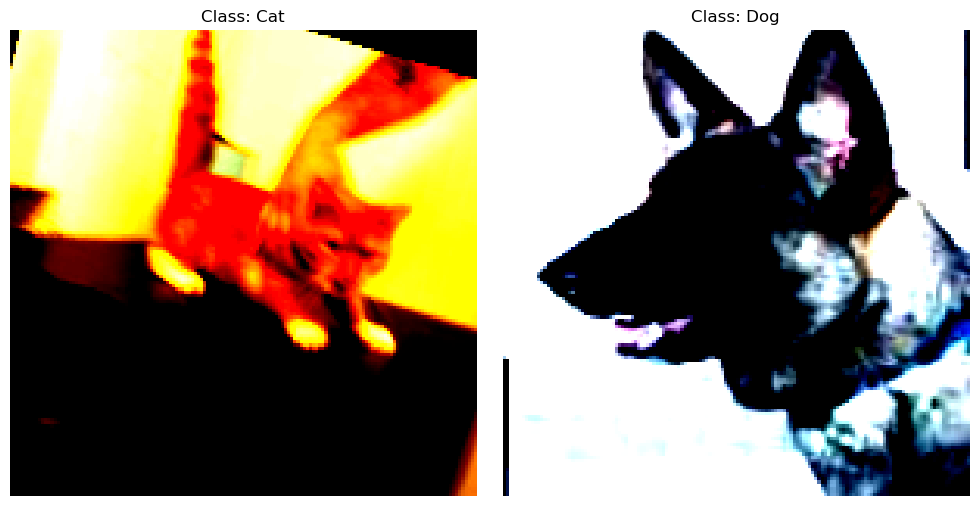

In [36]:
# 查看数据集图片

# 定义函数将 Tensor 转为 numpy 格式的图片
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))  # 将通道维度移到最后 (H, W, C)
    img = np.clip(img, 0, 1)  # 确保像素值在 [0, 1] 范围
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

# 获取两张不同类别的图像
def get_two_classes_samples(dataset):
    """
    高效获取数据集中每个类别的样本。
    """
    class_indices = {label: None for label in range(len(dataset.classes))}  # 存储每个类别的索引
    samples = {}  # 存储样本
    half_len = len(dataset) // 2  # 数据集一半的长度
    
    # 遍历前后索引寻找每个类别的第一个样本
    for idx in range(half_len):
        # 从前往后找
        _, label = dataset[idx]
        if class_indices[label] is None:
            class_indices[label] = idx  # 记录该类别的第一个样本索引
            samples[label] = dataset[idx][0]  # 存储对应的图片数据
        
        # 从后往前找
        _, label = dataset[len(dataset) - 1 - idx]
        if class_indices[label] is None:
            class_indices[label] = len(dataset) - 1 - idx
            samples[label] = dataset[len(dataset) - 1 - idx][0]
        
        # 如果已找到所有类别，停止搜索
        if len(samples) == len(dataset.classes):
            break

    return samples


# 从训练集获取两张不同类别的图像
class_samples = get_two_classes_samples(train_data)

# 可视化
plt.figure(figsize=(10, 5))
for i, (label, img) in enumerate(class_samples.items()):
    plt.subplot(1, 2, i+1)
    imshow(img, f"Class: {train_data.classes[label]}")
plt.tight_layout()
plt.show()

In [37]:
batch_size=32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size)

### 模型构建

`nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)`

卷积层输出计算公式：
$N = (W - F + 2P) / S + 1$
其中，
- N：输出大小
- W：输入大小
- F：卷积核大小
- P：填充值大小
- S：步长大小

In [38]:
class Net(torch.nn.Module):
    def __init__(self):
        # 输入形状: (batch, 3, 150, 150)
        super(Net, self).__init__()

        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 32, 150, 150)
            torch.nn.BatchNorm2d(32),  # 增加 Batch Normalization 提高训练稳定性
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 32, 75, 75)
        )

        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 64, 75, 75)
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 64, 37, 37)
        )

        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 128, 37, 37)
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 128, 18, 18)
        )
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 256, 18, 18)
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 256, 9, 9)
        )

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(256 * 9 * 9, 512),  # 全连接层, 输入: 128*18*18
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),  # 添加 Dropout 防止过拟合
            torch.nn.Linear(512, 2)  # 最后输出 2 个类别
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv1(x)  # 第一卷积模块
        x = self.conv2(x)  # 第二卷积模块
        x = self.conv3(x)  # 第三卷积模块
        x = self.conv4(x)  # 第四卷积模块
        x = x.view(batch_size, -1)  # 展平为全连接层输入
        x = self.fc(x)  # 全连接层
        return x  # 输出形状: (batch, 2)


In [39]:
model=Net().to(device)

lr=1e-3

# 定义损失函数和优化器
loss_fn = torch.nn.CrossEntropyLoss()  # 适用于多（二）分类问题, 适合模型输出为 (batch_size, class_num)
"""
权重衰减 (L2正则化)
在优化器中加入权重衰减，可以防止过拟合
大的权重值会导致模型对训练数据的拟合过度，从而丧失对新数据的泛化能力。
L2 正则化通过惩罚大权重值，迫使模型学到更平滑的特征分布，而不是依赖特定特征的绝对大小。
"""
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4) # 使用 Adam 优化器
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
"""
学习率衰减策略
StepLR: 每隔一定的步数衰减学习率
它会在每 step_size 个 epoch 后将学习率乘以一个因子 gamma
这种方法可以在模型训练进入瓶颈时，减少学习率，从而让优化器更精细地调整权重，避免震荡或错过局部最优
"""
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [40]:
# 查看模型结构
# 打印模型参数总数和可训练参数总数
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())  # 所有参数数量
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  # 需要训练的参数数量
    print(f"模型总参数数量: {total_params:,}")
    print(f"模型可训练参数数量: {trainable_params:,}")

print(model)
count_parameters(model)

Net(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(

In [41]:
# 训练函数
def train(dataloader, model, loss_fn, optimizer):
    model.train()  # 设置模型为训练模式
    running_loss = 0.0
    correct = 0
    total = 0

    # 使用 tqdm 包裹数据加载器，显示进度条 (因为训练过程会比较慢)
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for images, labels in progress_bar:
        # 将数据移动到设备
        images, labels = images.to(device), labels.to(device)

        # 前向传播
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # 反向传播和优化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()  # 更新模型参数

        # 统计指标
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 更新进度条描述
        progress_bar.set_postfix(loss=loss.item())
        
    scheduler.step()  # 更新学习率

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(dataloader)
    return avg_loss, accuracy

In [42]:
# 测试函数
def evaluate(dataloader, model, loss_fn):
    model.eval()  # 设置模型为评估模式
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # 关闭梯度计算
        progress_bar = tqdm(dataloader, desc="Evaluating", leave=False)
        for images, labels in dataloader:
            # 将数据移动到设备
            images, labels = images.to(device), labels.to(device)

            # 前向传播
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            # 统计指标
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            # 更新进度条描述
            progress_bar.set_postfix(loss=loss.item())

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(dataloader)
    return avg_loss, accuracy

### 模型训练

In [43]:
# 开始训练
"""
如果不想训练太久可以适当减小epoch
epoch=10的时候训练正确率就达到了77.0%, epoch=30时才为81.0% 
再增加epoch训练效果增加不明显, 但是结果明显还未收敛。
为了更好的效果作者就增大了epoch
"""
num_epochs = 20

train_loss = []
train_acc  = []
test_loss  = []
test_acc   = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    
    epoch_train_loss, epoch_train_acc = train(train_loader, model, loss_fn, optimizer)

    # 在测试集上评估
    epoch_test_loss, epoch_test_acc = evaluate(test_loader, model, loss_fn)

    train_acc.append(epoch_train_acc)
    train_loss.append(epoch_train_loss)
    test_acc.append(epoch_test_acc)
    test_loss.append(epoch_test_loss)
    # 打印训练和测试结果
    template = ('Epoch:{:2d}, Train_acc:{:.1f}%, Train_loss:{:.3f}, Test_acc:{:.1f}%，Test_loss:{:.3f}')
    print(template.format(epoch+1, epoch_train_acc, epoch_train_loss, epoch_test_acc, epoch_test_loss))

print("训练完成!")

Epoch 1/20


Training:  53%|█████▎    | 370/704 [05:15<04:52,  1.14it/s, loss=0.605]d:\CodeTools\anaconda3\envs\myenv\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch: 1, Train_acc:71.2%, Train_loss:0.565, Test_acc:79.6%，Test_loss:0.458
Epoch 2/20


Epoch: 2, Train_acc:79.1%, Train_loss:0.445, Test_acc:81.6%，Test_loss:0.418
Epoch 3/20


Epoch: 3, Train_acc:82.4%, Train_loss:0.392, Test_acc:81.9%，Test_loss:0.423
Epoch 4/20


...

Epoch:16, Train_acc:92.4%, Train_loss:0.185, Test_acc:91.7%，Test_loss:0.233
Epoch 17/20


Epoch:17, Train_acc:92.8%, Train_loss:0.183, Test_acc:90.9%，Test_loss:0.223
Epoch 18/20


Epoch:18, Train_acc:92.8%, Train_loss:0.183, Test_acc:91.7%，Test_loss:0.239
Epoch 19/20


Epoch:19, Train_acc:92.8%, Train_loss:0.182, Test_acc:91.4%，Test_loss:0.214
Epoch 20/20


Epoch:20, Train_acc:92.9%, Train_loss:0.179, Test_acc:91.8%，Test_loss:0.210
训练完成!


### 结果可视化

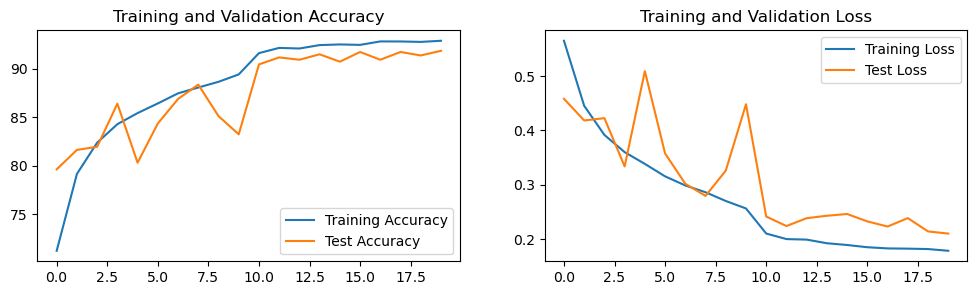

In [44]:
epochs_range = range(num_epochs)

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)

plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, test_acc, label='Test Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, test_loss, label='Test Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### 模型保存

In [46]:
# 指定保存路径
save_dir = 'D:\\studyWork\\deepLearning\\models\\2_Cat_Dog_Image_Classification'

# 确保目录存在，如果不存在则创建
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 保存模型
torch.save(model.state_dict(), os.path.join(save_dir, 'model_weights.pth'))

# # 加载模型参数
# model.load(torch.load(os.path.join(save_dir, 'model_weights.pth')))

## 加载本地保存的模型，对本地猫狗图片进行分类预测

In [47]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

In [48]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [50]:
class Net(torch.nn.Module):
    def __init__(self):
        # 输入形状: (batch, 3, 150, 150)
        super(Net, self).__init__()

        self.conv1 = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 32, 150, 150)
            torch.nn.BatchNorm2d(32),  # 增加 Batch Normalization 提高训练稳定性
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 32, 75, 75)
        )

        self.conv2 = torch.nn.Sequential(
            torch.nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 64, 75, 75)
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 64, 37, 37)
        )

        self.conv3 = torch.nn.Sequential(
            torch.nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 128, 37, 37)
            torch.nn.BatchNorm2d(128),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 128, 18, 18)
        )
        self.conv4 = torch.nn.Sequential(
            torch.nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),  # 输出: (batch, 256, 18, 18)
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2)  # 输出: (batch, 256, 9, 9)
        )

        self.fc = torch.nn.Sequential(
            torch.nn.Linear(256 * 9 * 9, 512),  # 全连接层, 输入: 256*9*9
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),  # 添加 Dropout 防止过拟合
            torch.nn.Linear(512, 2)  # 最后输出 2 个类别
        )

    def forward(self, x):
        batch_size = x.size(0)
        x = self.conv1(x)  # 第一卷积模块
        x = self.conv2(x)  # 第二卷积模块
        x = self.conv3(x)  # 第三卷积模块
        x = self.conv4(x)  # 第四卷积模块
        x = x.view(batch_size, -1)  # 展平为全连接层输入
        x = self.fc(x)  # 全连接层
        return x  # 输出形状: (batch, 2)

model = Net().to(device)
model_path = 'D:\\studyWork\\deepLearning\\models\\2_Cat_Dog_Image_Classification\\model_weights.pth'
# 加载模型参数
model.load_state_dict(torch.load(model_path))
# 将模型设置为评估模式
model.eval()

Net(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(

In [51]:
# 预测函数
def predict_image(image_path, model, classes=['Cat', 'Dog']):
    image = Image.open(image_path)
    # 图像预处理  与模型训练数据处理匹配
    transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),  # 随机水平翻转，增强样本的多样性，概率为 50%
        transforms.RandomRotation(15),  # 随机旋转图像，角度范围为 -15° 到 15°
        transforms.ColorJitter(          # 随机调整图像的颜色属性：
            brightness=0.01,             # 调整亮度，范围为 [0.8, 1.2]（1±0.2）
            contrast=0.01,               # 调整对比度，范围为 [0.8, 1.2]
            saturation=0.01,             # 调整饱和度，范围为 [0.8, 1.2]
            hue=0.01                     # 调整色调，范围为 [-0.1, 0.1]
        ),
        transforms.RandomResizedCrop(150, scale=(0.8, 1.0)),  # 把图片的每一个channel随机裁剪成 150x150, 裁剪比例范围为 80% - 100%
        transforms.ToTensor(),             # 将图像转换为张量，并将像素值归一化到 [0, 1]
        transforms.Normalize(              # 对张量进行标准化处理, 提升模型训练的稳定性
            mean=[0.485, 0.456, 0.406],    # 使用 ImageNet 数据集的均值
            std=[0.229, 0.224, 0.225]      # 使用 ImageNet 数据集的标准差
        ),
    ])
    image = transform(image)
    image = image.to(device)
    image = image.unsqueeze(0)
    
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output.data, 1)
    return classes[predicted.item()]

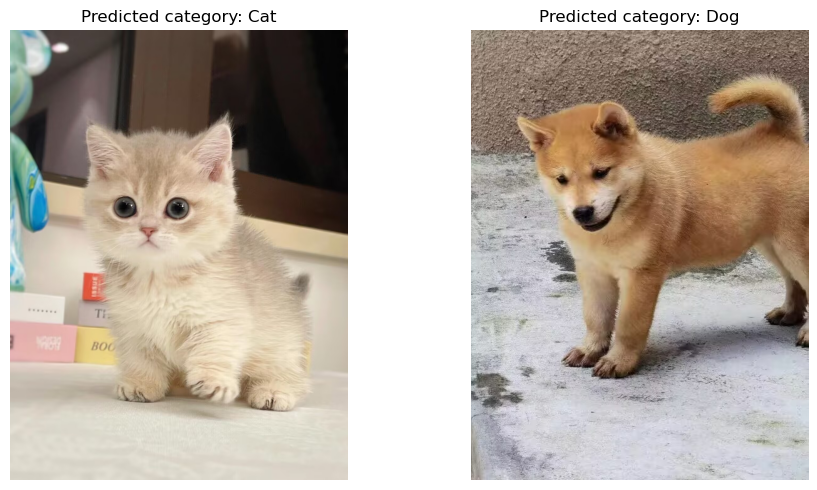

In [56]:
#展示图片及它们对应的预测标签

cat_path = 'D:\\studyWork\\deepLearning\\data\\cat.jpg'
dog_path = 'D:\\studyWork\\deepLearning\\data\\dog.jpg'

# 显示图像及预测结果
plt.figure(figsize=(10, 5))

# 猫图像
plt.subplot(1, 2, 1)
cat_predicted = predict_image(cat_path, model)
plt.imshow(Image.open(cat_path))
plt.title(f"Predicted category: {cat_predicted}")
plt.axis('off')

# 狗图像
plt.subplot(1, 2, 2)
dog_predicted = predict_image(dog_path, model)
plt.imshow(Image.open(dog_path))
plt.title(f"Predicted category: {dog_predicted}")
plt.axis('off')

# 显示结果
plt.tight_layout()
plt.show()